In [1]:
import pandas as pd

# Charger le fichier (si ce n'est pas déjà fait)
df = pd.read_feather("data_indian_ocean.feather")

# Option 1 : Afficher sous forme de liste brute (tout d'un coup)
print(df.columns.tolist())

# Option 2 : Afficher une colonne par ligne (plus lisible pour copier-coller)
print("\n--- Liste des Colonnes ---")
for col in df.columns:
    print(col)

['imo', 'mmsi', 'name', 'latitude', 'longitude', 'timestamp', 'sog', 'cog', 'nav status', 'nav status code', 'draft', 'time delta (s)', 'destination', 'information source', 'checked status', 'load type', 'voyage number', 'origin->destination', 'at port', 'port stay type', 'wave period Tp (s)', 'significant wave height Hs (m)', 'mean wave direction (°)', 'sea surface temperature (°K)', 'air temperature at 2m (°K)', 'eastward wind velocity (m/s)', 'northward wind velocity (m/s)', 'mean wave direction relative to vessel (°)']

--- Liste des Colonnes ---
imo
mmsi
name
latitude
longitude
timestamp
sog
cog
nav status
nav status code
draft
time delta (s)
destination
information source
checked status
load type
voyage number
origin->destination
at port
port stay type
wave period Tp (s)
significant wave height Hs (m)
mean wave direction (°)
sea surface temperature (°K)
air temperature at 2m (°K)
eastward wind velocity (m/s)
northward wind velocity (m/s)
mean wave direction relative to vessel (°)

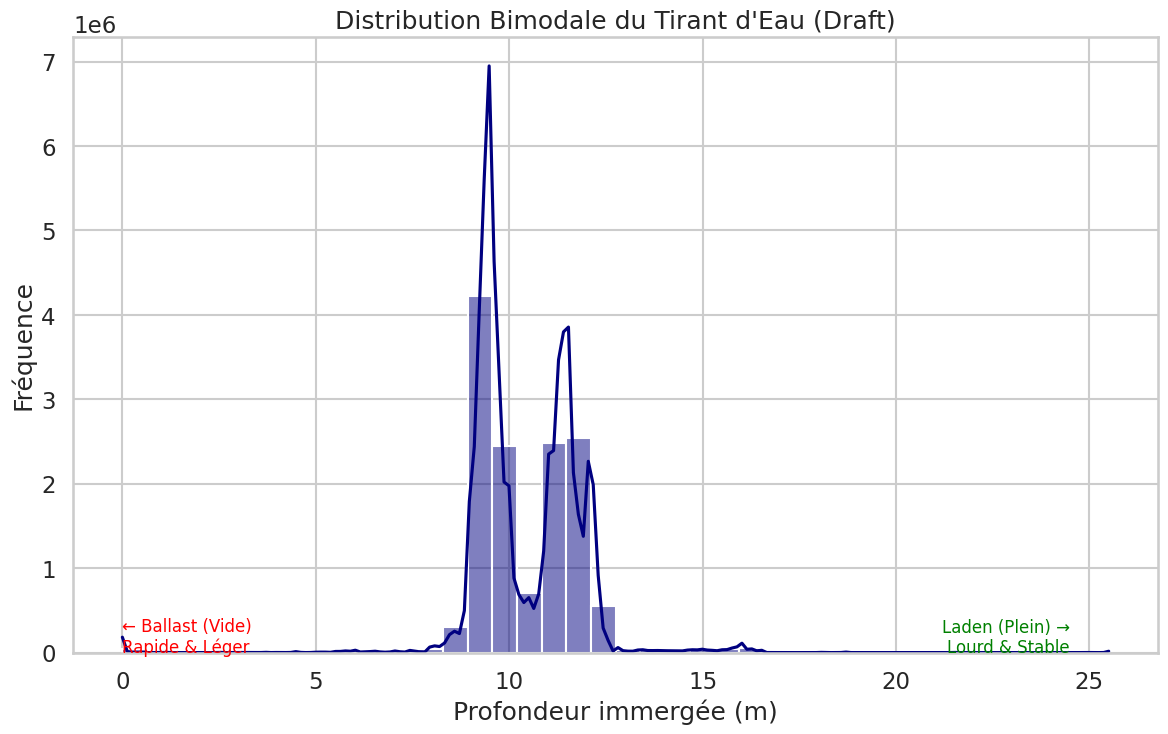

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (14, 8)

# Chargement
df = pd.read_feather("data_indian_ocean.feather")

# =============================================================================
# GRAPHIQUE 1 : ANALYSE DU DRAFT (CHARGEMENT)
# =============================================================================
plt.figure()
# Utilisation de la colonne 'draft' (et non 'draught')
sns.histplot(df['draft'].dropna(), bins=40, kde=True, color='navy')
plt.title("Distribution Bimodale du Tirant d'Eau (Draft)")
plt.xlabel("Profondeur immergée (m)")
plt.ylabel("Fréquence")

# Annotation ENSAE : On explique les modes
plt.text(df['draft'].min(), 100, "← Ballast (Vide)\nRapide & Léger", color='red', fontsize=12)
plt.text(df['draft'].max()-1, 100, "Laden (Plein) →\nLourd & Stable", color='green', fontsize=12, ha='right')
plt.show()

# =============================================================================
# GRAPHIQUE 2 : PHYSIQUE DE LA VAGUE
# =============================================================================
# Vous avez déjà la direction relative ! C'est une chance.
# 'mean wave direction relative to vessel (°)'
# 0° = Vagues de face (Résistance Max), 180° = Vagues de dos (Surf)

plt.figure()
# On filtre les valeurs aberrantes de vagues (> 8m pour la visi)
subset = df[df['significant wave height Hs (m)'] < 8]

# Scatter plot coloré par l'angle d'attaque
sc = plt.scatter(subset['significant wave height Hs (m)'], subset['sog'], 
                 c=subset['mean wave direction relative to vessel (°)'], 
                 cmap='twilight', alpha=0.5, s=10)

plt.colorbar(sc, label="Angle Vague Relatif (0°=Face, 180°=Dos)")
plt.title("Impact des Vagues sur la Vitesse (Coloré par Direction Relative)")
plt.xlabel("Hauteur de Vague Hs (m)")
plt.ylabel("Vitesse SOG (nds)")

# Tendance globale (Régression non-paramétrique Lowess)
sns.regplot(x='significant wave height Hs (m)', y='sog', data=subset, 
            scatter=False, lowess=True, color='red', line_kws={'lw': 3, 'label': 'Tendance Moyenne'})
plt.legend()
plt.show()

# =============================================================================
# GRAPHIQUE 3 : CORRÉLATION PHYSIQUE
# =============================================================================
cols_physiques = [
    'sog', 
    'draft', 
    'significant wave height Hs (m)', 
    'wave period Tp (s)',
    'mean wave direction relative to vessel (°)',
    'eastward wind velocity (m/s)'
]

plt.figure(figsize=(10, 8))
corr = df[cols_physiques].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice de Corrélation des Variables Physiques")
plt.show()